<a href="https://colab.research.google.com/github/mallelamanojkumar90/AIML/blob/main/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Understanding XGBoost (Extreme Gradient Boosting)

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. XGBoost provides a parallel tree boosting (also known as GBDT, GBM) that solves many data science problems in a fast and accurate way.

### Key Features of XGBoost:

*   **Scalable**: It runs on a single machine or in distributed environments (Hadoop, Spark, Flink).
*   **High Performance**: It's known for its speed and often wins machine learning competitions.
*   **Regularization**: It includes L1 and L2 regularization to prevent overfitting.
*   **Handling Missing Values**: It has a built-in mechanism to handle missing values automatically.
*   **Flexibility**: It supports different objective functions, including regression, classification, and ranking.

### How XGBoost Works (High-Level Overview)

At its core, XGBoost is an ensemble learning method that sequentially builds multiple decision trees. Here's a simplified breakdown:

1.  **Starts with an initial prediction**: This can be a simple model or even just the average of the target variable.
2.  **Iteratively builds new trees**: Each new tree is trained to predict the *residuals* (the errors) of the previous tree's predictions, not the actual target variable.
3.  **Adds predictions to the ensemble**: The predictions from each new tree are added to the ensemble, with a small learning rate (shrinkage) to prevent overfitting.
4.  **Optimizes with Gradient Descent**: It uses gradient descent to minimize the loss function by iteratively improving the model's predictions.

This iterative process of correcting errors leads to a strong predictive model built from many weak predictive models (decision trees).

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# 1. Generate some synthetic data for a regression problem
np.random.seed(42)
num_samples = 1000

X = np.random.rand(num_samples, 3) * 10 # 3 features, values between 0 and 10
y = 2 * X[:, 0] + 1.5 * X[:, 1] - 0.5 * X[:, 2] + np.random.randn(num_samples) * 2 + 5 # Target with some noise

# Convert to DataFrame for better readability
df = pd.DataFrame(X, columns=['Feature_A', 'Feature_B', 'Feature_C'])
df['Target'] = y

display(df.head())

,Feature_A,Feature_B,Feature_C,Target
0,3.745401,9.507143,7.319939,25.211420
1,5.986585,1.560186,1.559945,19.767489
2,0.580836,8.661761,6.011150,17.515878
3,7.080726,0.205845,9.699099,11.888758
4,8.324426,2.123391,1.818250,26.348703


### Example Data Explanation

We've generated a synthetic dataset with 1000 samples and 3 features (`Feature_A`, `Feature_B`, `Feature_C`). The `Target` variable is a linear combination of these features with some added random noise. This type of data is suitable for a regression task, where we want to predict a continuous target variable.

In [7]:
# 2. Split the data into training and testing sets
X = df[['Feature_A', 'Feature_B', 'Feature_C']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 3. Initialize and train the XGBoost Regressor model

# Define XGBoost parameters
params = {
    'objective': 'reg:squarederror',  # Objective function for regression tasks
    'eval_metric': 'rmse',            # Evaluation metric (Root Mean Squared Error)
    'eta': 0.1,                       # Learning rate
    'max_depth': 5,                   # Maximum depth of a tree
    'subsample': 0.8,                 # Subsample ratio of the training instance
    'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
    'random_state': 42
}

# Initialize the XGBoost Regressor model
model = xgb.XGBRegressor(**params)

# Train the model
print("\nTraining XGBoost model...")
model.fit(X_train, y_train)

print("XGBoost model training complete!")

Training data shape: (800, 3)
Testing data shape: (200, 3)

Training XGBoost model...
XGBoost model training complete!



Root Mean Squared Error (RMSE) on test set: 2.3154


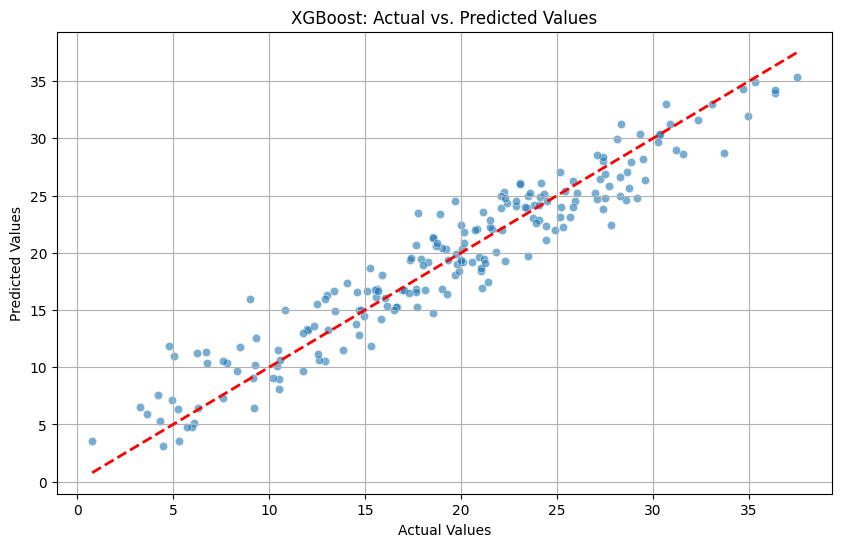

<Figure size 800x500 with 0 Axes>

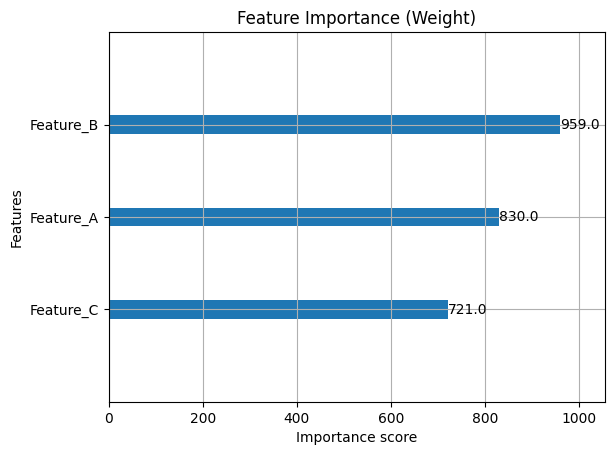

In [8]:
# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nRoot Mean Squared Error (RMSE) on test set: {rmse:.4f}")

# Visualize predictions vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBoost: Actual vs. Predicted Values")
plt.grid(True)
plt.show()

# Display feature importances
plt.figure(figsize=(8, 5))
xgb.plot_importance(model, importance_type='weight', title='Feature Importance (Weight)')
plt.show()

### Example Summary

In this example, we demonstrated how to:

1.  **Generate synthetic data** for a regression task.
2.  **Split the data** into training and testing sets.
3.  **Initialize and train an `xgb.XGBRegressor` model** with specified parameters. We used `objective='reg:squarederror'` for regression and `eval_metric='rmse'` to monitor performance during training.
4.  **Make predictions** on unseen test data.
5.  **Evaluate the model** using Root Mean Squared Error (RMSE), which measures the average magnitude of the errors. A lower RMSE indicates a better fit.
6.  **Visualize the results** by plotting actual vs. predicted values and showing feature importances. The feature importance plot helps understand which features contributed most to the model's predictions.

The scatter plot shows how closely our predictions align with the actual values. A perfect model would have all points lying on the red dashed line (where Actual = Predicted).